In [42]:
import numpy as np
import matplotlib.pyplot as plt
from PyEMD import CEEMDAN
from scipy.signal import resample

def double_cascaded_moving_average(signal, window_size=5):
    # First pass
    smooth1 = np.convolve(signal, np.ones(window_size)/window_size, mode='same')
    # Second pass
    smooth2 = np.convolve(smooth1, np.ones(window_size)/window_size, mode='same')
    return smooth2

def normalize_signal(signal):
    max_val = np.max(np.abs(signal))
    if max_val == 0:
        return signal
    return signal / max_val

def resample_to_fixed_length(signal, target_length=8192):
    return resample(signal, target_length)

def load_vag_signals(healthy_dir, pathology_dir):
    healthy_signals = []
    pathology_signals = []

    healthy_files = [f for f in os.listdir(healthy_dir) if '.ipynb_checkpoints' not in f]
    pathology_files = [f for f in os.listdir(pathology_dir) if '.ipynb_checkpoints' not in f]

    print(f"Loaded {len(healthy_files)} healthy VAG signals")
    print(f"Loaded {len(pathology_files)} pathology VAG signals")

    max_size_files = max(len(healthy_files), len(pathology_files))

    for i in range(max_size_files):
        if i < len(healthy_files):
            file_path = os.path.join(healthy_dir, healthy_files[i])
            with open(file_path, 'r') as file:
                vags = [float(x) for x in file.read().split()]
                healthy_signals.append(vags)

        if i < len(pathology_files):
            file_path = os.path.join(pathology_dir, pathology_files[i])
            with open(file_path, 'r') as file:
                vags = [float(x) for x in file.read().split()]
                pathology_signals.append(vags)

    return healthy_signals, pathology_signals  

def plot_raw_vs_filtered(healthy_signals, pathology_signals, num_samples=5):
    """Plot raw and filtered versions of VAG signals from healthy and pathological groups."""
    fig, axes = plt.subplots(2 * num_samples, 2, figsize=(14, num_samples * 4))

    for i in range(num_samples):
        raw_healthy = healthy_signals[i]
        filtered_healthy = double_cascaded_moving_average(raw_healthy)
        norm_healthy =  normalize_signal(filtered_healthy)

        raw_pathology = pathology_signals[i]
        filtered_pathology = double_cascaded_moving_average(raw_pathology)
        norm_pathology = normalize_signal(filtered_pathology)
        # Plot Healthy
        axes[2*i][0].plot(raw_healthy, color='gray')
        axes[2*i][0].set_title(f"Healthy #{i+1} - Raw")

        axes[2*i + 1][0].plot(norm_healthy, color='green')
        axes[2*i + 1][0].set_title(f"Healthy #{i+1} - Filtered")

        # Plot Pathology
        axes[2*i][1].plot(raw_pathology, color='gray')
        axes[2*i][1].set_title(f"Pathology #{i+1} - Raw")

        axes[2*i + 1][1].plot(norm_pathology, color='red')
        axes[2*i + 1][1].set_title(f"Pathology #{i+1} - Filtered")

    plt.tight_layout()
    plt.show()

Loaded 51 healthy VAG signals
Loaded 38 pathology VAG signals


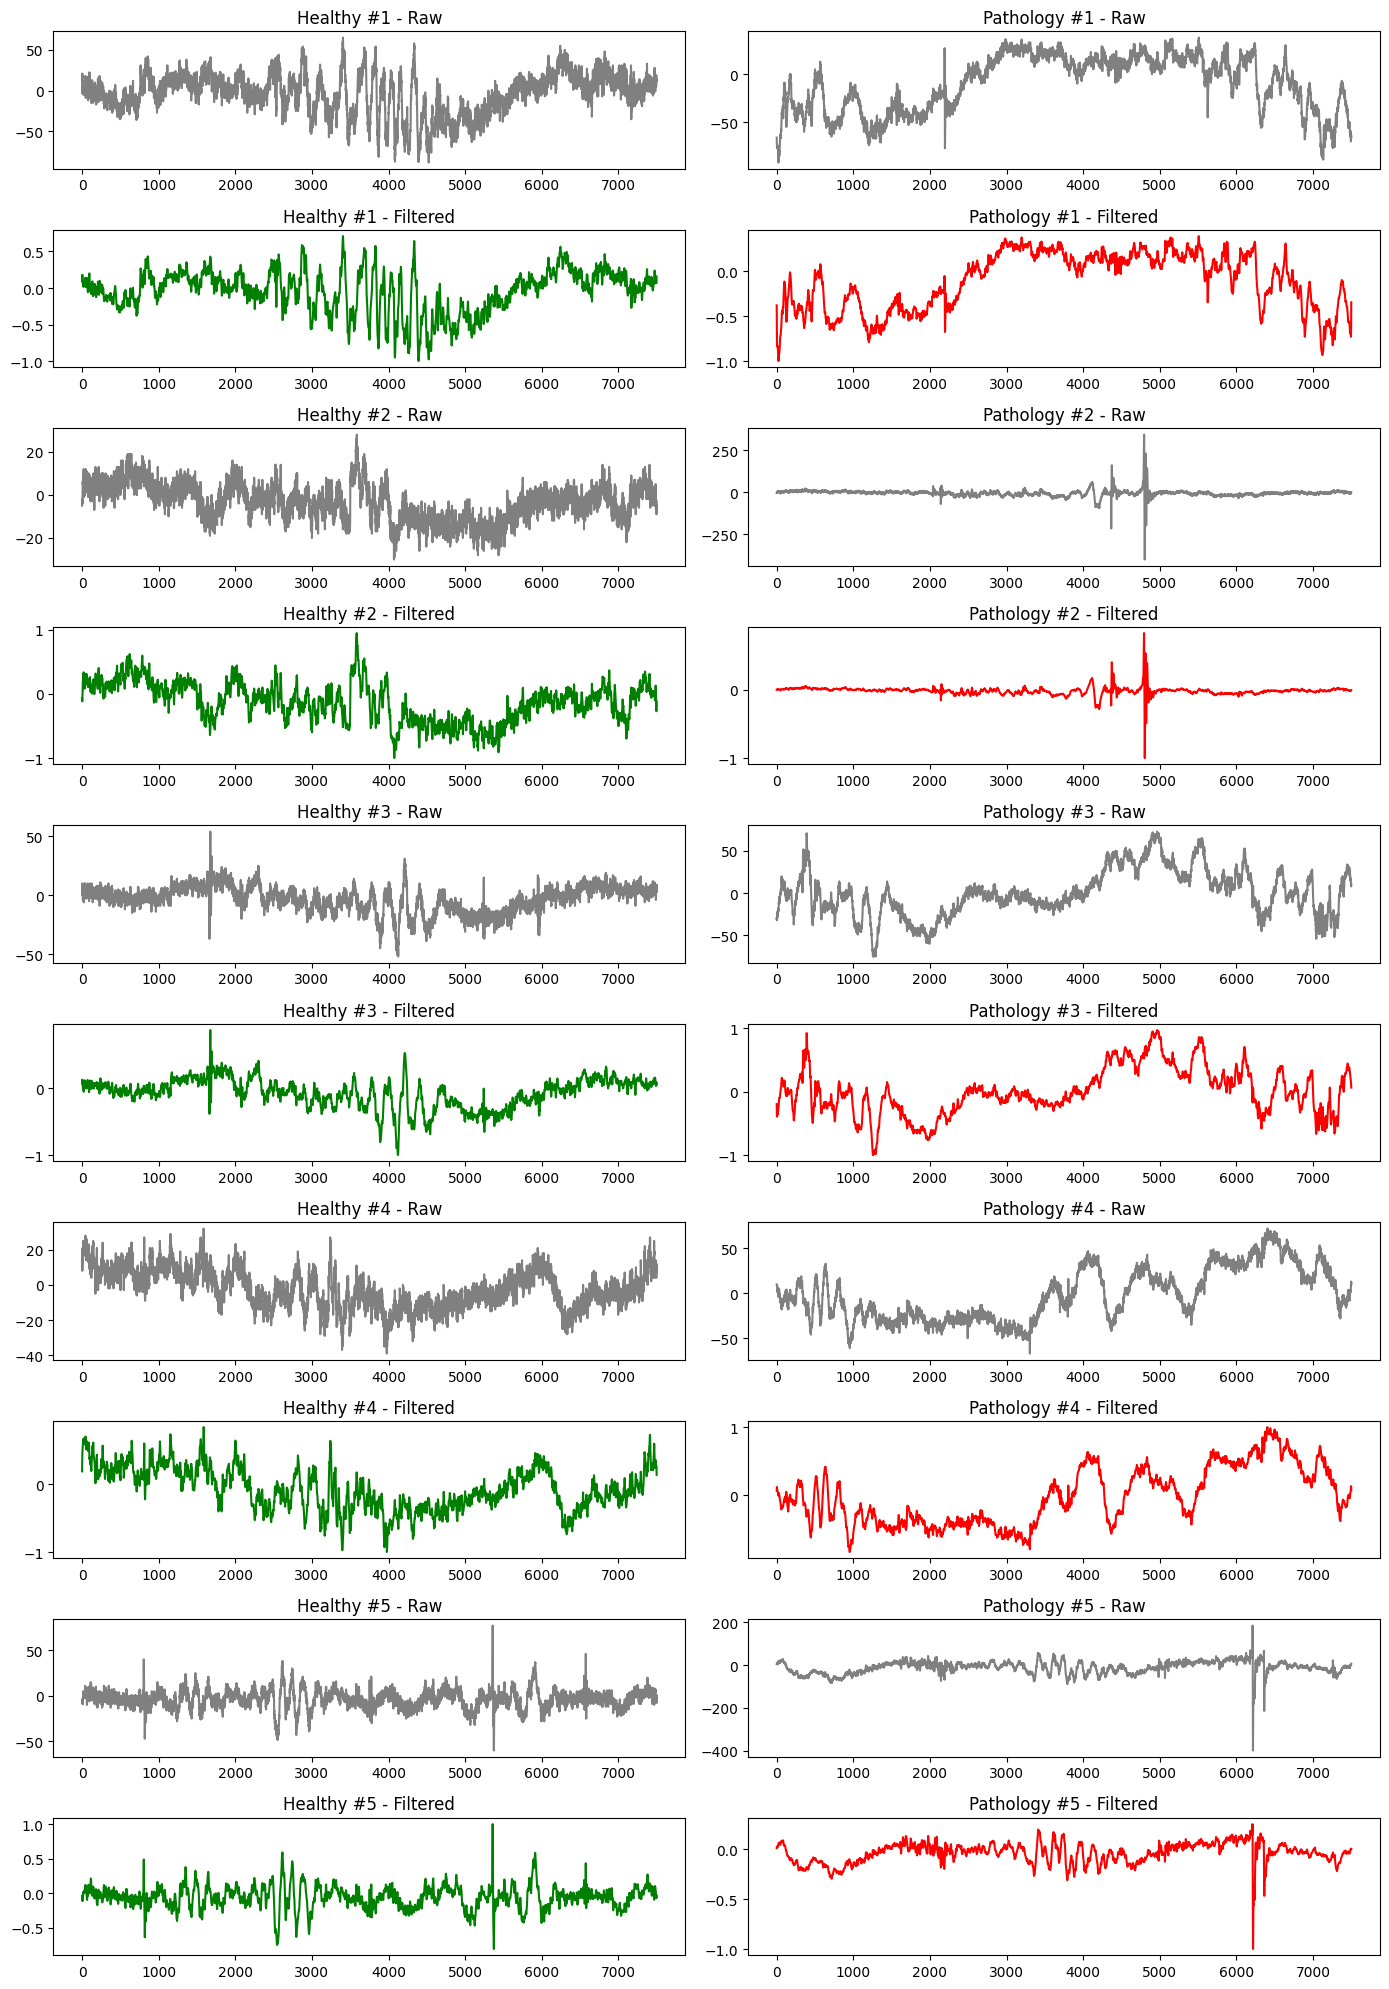

In [43]:

healthy_dir = "../data/open_vag/normal/"
pathology_dir = "../data/open_vag/pathology/"
h, p = load_vag_signals(healthy_dir, pathology_dir)

plot_raw_vs_filtered(h, p)

window_size = 5
def preprocess_vag(signal, window):
    f_signal = double_cascaded_moving_average(signal, window_size=window)
    n_signal = normalize_signal(f_signal)
    n_signal = resample_to_fixed_length(n_signal)
    return n_signal

norm_h = []
for s in h:
    s_n = preprocess_vag(s, window_size)
    norm_h.append(s_n)

norm_p = []
for s in p:
    s_n = preprocess_vag(s, window_size)
    norm_p.append(s_n)

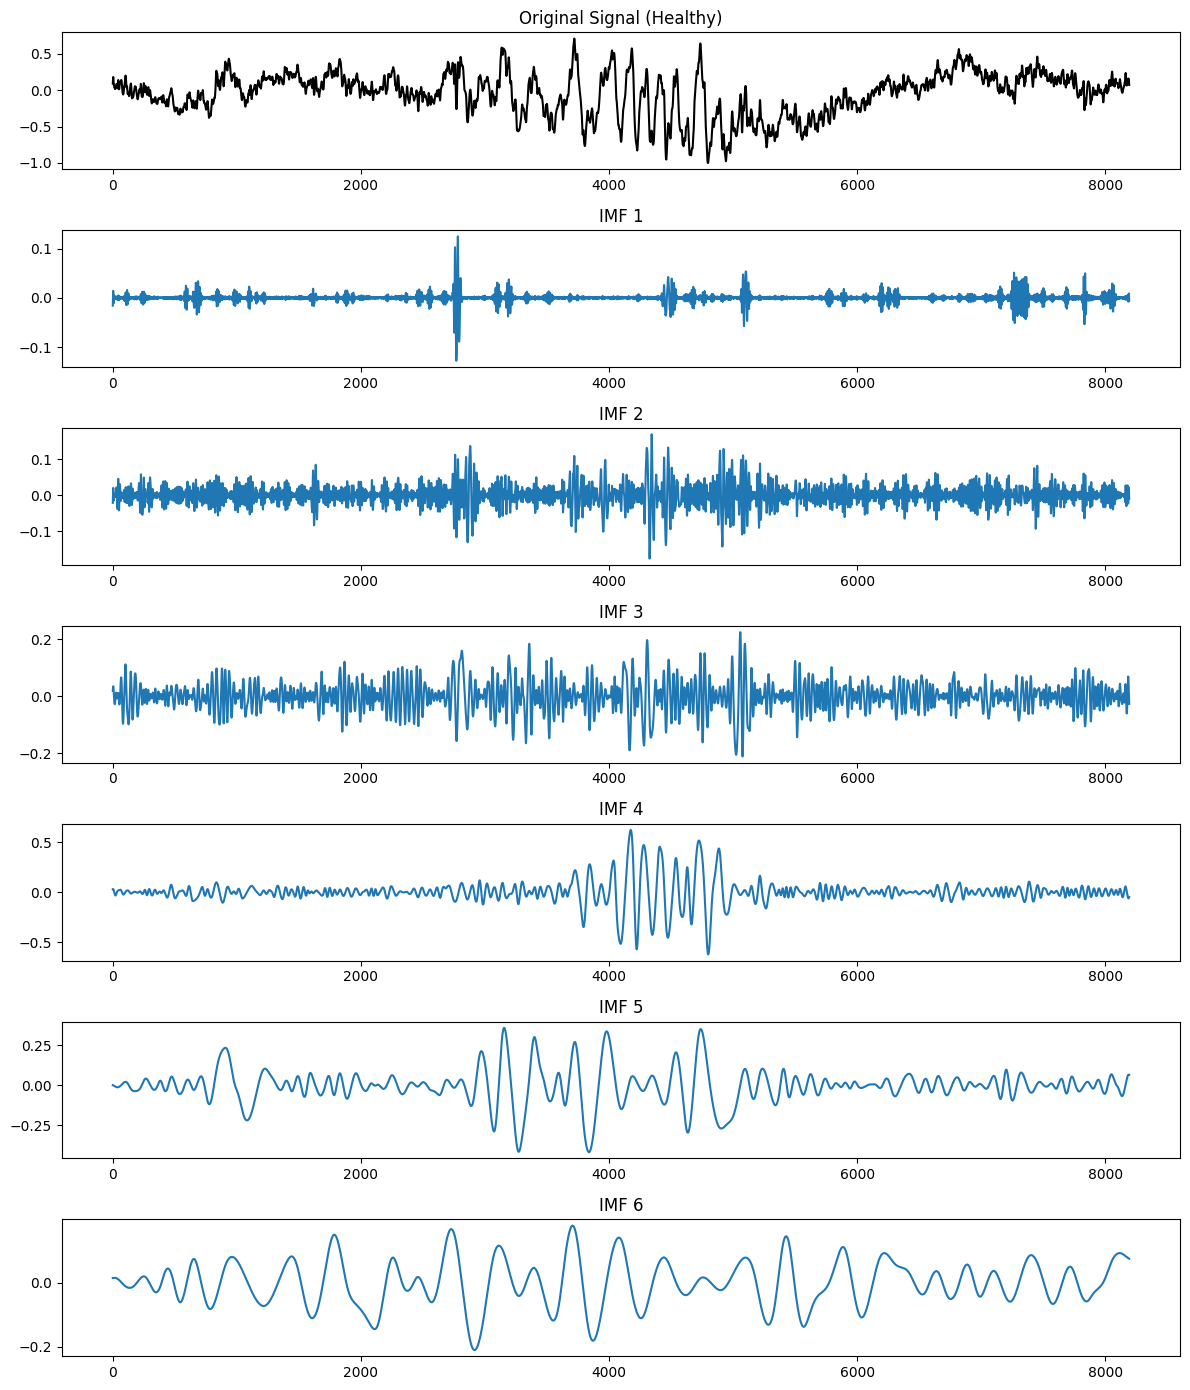

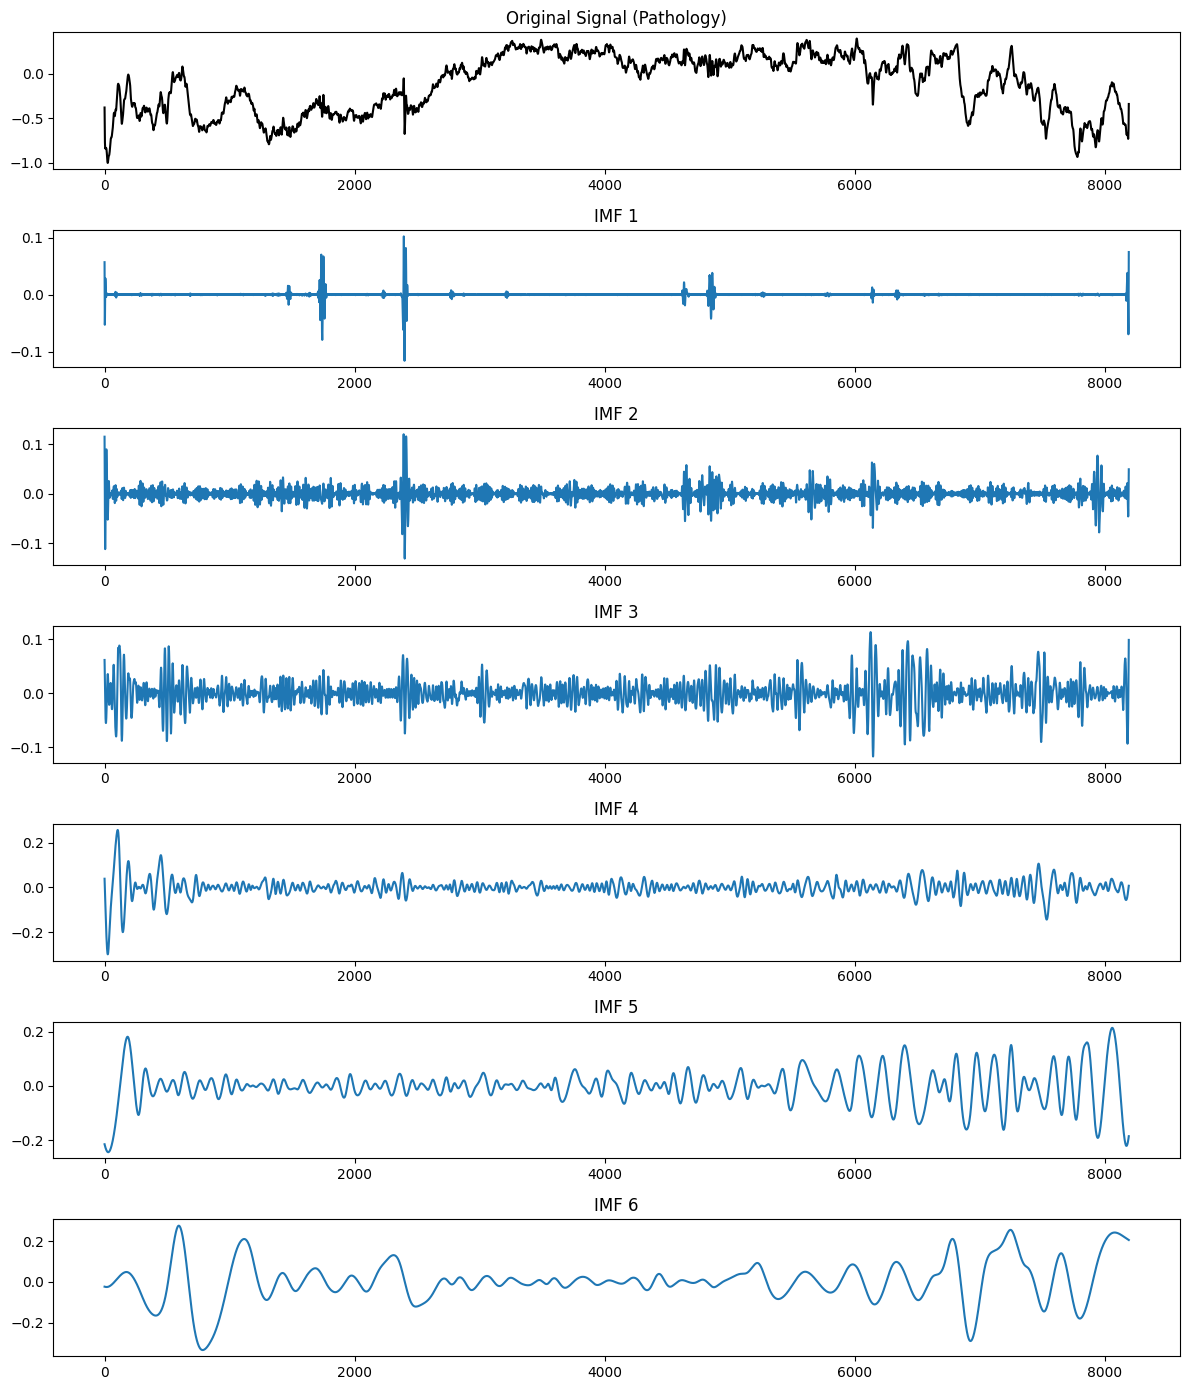

In [44]:
# norm_h and norm_p
def apply_ceemdan(signal, noise_seed=42):
    ceemdan = CEEMDAN()
    ceemdan.noise_seed(noise_seed)
    IMFs = ceemdan(signal)
    return IMFs

def plot_imfs(signal, label, num_imfs_to_plot=6):
    imfs = apply_ceemdan(signal)
    num_imfs = min(num_imfs_to_plot, imfs.shape[0])

    plt.figure(figsize=(12, 2 * (num_imfs + 1)))
    plt.subplot(num_imfs + 1, 1, 1)
    plt.plot(signal, color='black')
    plt.title(f"Original Signal ({label})")
    
    for i in range(num_imfs):
        plt.subplot(num_imfs + 1, 1, i + 2)
        plt.plot(imfs[i])
        plt.title(f"IMF {i + 1}")
    
    plt.tight_layout()
    plt.show()

plot_imfs(norm_h[0], label="Healthy")
plot_imfs(norm_p[0], label="Pathology")

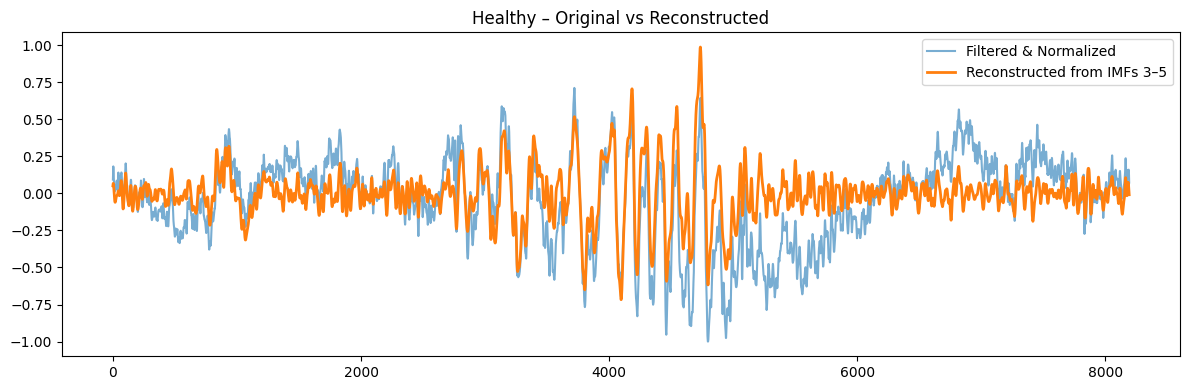

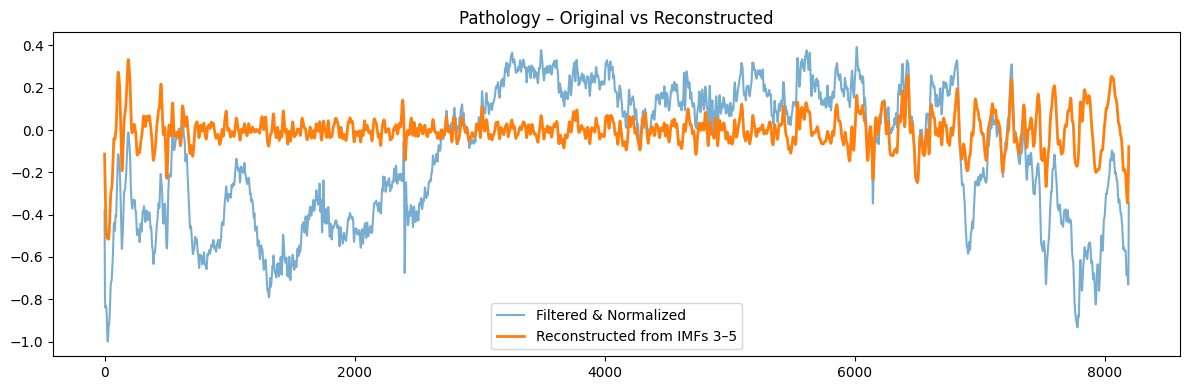

In [45]:
def ceemdan_reconstruct_midband(signal, imf_range=(2, 5), noise_seed=42):
    """
    Decompose a signal using CEEMDAN and reconstruct using only IMFs 3–5.
    
    Parameters:
        signal (np.array): The input signal
        imf_range (tuple): Index range of IMFs to retain (Python index, 0-based)
        noise_seed (int): Seed for reproducibility

    Returns:
        imfs (np.array): All IMFs
        reconstructed (np.array): Reconstructed signal using selected IMFs
    """
    ceemdan = CEEMDAN()
    ceemdan.noise_seed(noise_seed)
    imfs = ceemdan(signal)

    start, end = imf_range
    reconstructed = np.sum(imfs[start:end], axis=0)
    return imfs, reconstructed

def plot_original_vs_reconstructed(signal, reconstructed, label="Signal"):
    plt.figure(figsize=(12, 4))
    plt.plot(signal, label="Filtered & Normalized", alpha=0.6)
    plt.plot(reconstructed, label="Reconstructed from IMFs 3–5", linewidth=2)
    plt.title(f"{label} – Original vs Reconstructed")
    plt.legend()
    plt.tight_layout()
    plt.show()

# Choose one sample from each class
sample_h = norm_h[0]
sample_p = norm_p[0]

# CEEMDAN + Reconstruction
imfs_h, recon_h = ceemdan_reconstruct_midband(sample_h)
imfs_p, recon_p = ceemdan_reconstruct_midband(sample_p)

# Plot
plot_original_vs_reconstructed(sample_h, recon_h, label="Healthy")
plot_original_vs_reconstructed(sample_p, recon_p, label="Pathology")

In [48]:
import numpy as np
from scipy.signal import hilbert, convolve

def separable_kernel_smooth(W, doppler_kernel, lag_kernel):
    # Convolve along time axis (axis=1) with Doppler kernel
    # Use 'same' mode to keep the shape
    smooth_time = np.apply_along_axis(lambda m: np.convolve(m, doppler_kernel, mode='same'), axis=1, arr=W)

    # Convolve along frequency axis (axis=0) with lag kernel
    smooth_freq_time = np.apply_along_axis(lambda m: np.convolve(m, lag_kernel, mode='same'), axis=0, arr=smooth_time)

    return smooth_freq_time

# === Your code ===

# Step 1: Compute analytic signal
x = recon_h  # your reconstructed signal array
z = hilbert(x)

# Step 2: Compute Wigner-Ville Distribution
wvd = WignerVilleDistribution(z)
W, ts, freqs = wvd.run()

print("Original WVD shape:", W.shape)       # e.g., (7500, 7500)

# Kernel sizes
doppler_len = 256
lag_len = 128

doppler_kernel = np.hanning(doppler_len)
lag_kernel = np.hanning(lag_len)

# Apply separable smoothing
QTFD_full = separable_kernel_smooth(W, doppler_kernel, lag_kernel)
print("Smoothed QTFD shape:", QTFD_full.shape)

# Step 3: Downsample to 256x128 for memory efficiency
# Compute downsampling factors
time_factor = W.shape[1] // doppler_len  # e.g., 7500//256 ~ 29
freq_factor = W.shape[0] // lag_len      # e.g., 7500//128 ~ 58
print("original time_factor", time_factor)
print("orginal freq_factor", freq_factor)
time_factor = 8192 // 256  # = 32
freq_factor = 8192 // 128  # = 64
print("new time_factor", time_factor)
print("new freq_factor", freq_factor)


# Downsample by averaging blocks
def block_average(mat, block_size_freq, block_size_time):
    new_shape = (mat.shape[0]//block_size_freq, block_size_freq,
                 mat.shape[1]//block_size_time, block_size_time)
    return mat.reshape(new_shape).mean(axis=(1,3))

QTFD_downsampled = block_average(QTFD_full, freq_factor, time_factor)
print("Downsampled QTFD shape:", QTFD_downsampled.shape)  # (128, 256)

# Optional: transpose to (time, freq) if needed
QTFD_downsampled = QTFD_downsampled.T  # shape (256, 128)

# Now you can use QTFD_downsampled as your time-frequency image for training


Original WVD shape: (8192, 8192)
Smoothed QTFD shape: (8192, 8192)
original time_factor 32
orginal freq_factor 64
new time_factor 32
new freq_factor 64
Downsampled QTFD shape: (128, 256)


In [52]:
import librosa.display

def plot_and_save_tfd_image(tfd_matrix, filename=None):
    plt.figure(figsize=(4, 4))
    librosa.display.specshow(tfd_matrix, sr=1, hop_length=1, x_axis='time', y_axis='linear', cmap='magma')
    plt.colorbar(format='%+2.0f dB')
    plt.title('Time-Frequency Distribution')
    plt.tight_layout()
    if filename:
        plt.savefig(filename)
        plt.close()
    else:
        plt.show()

plot_and_save_tfd_image(QTFD_downsampled, filename="tfd_reconstructed.png")


In [54]:
import os
import numpy as np
import pandas as pd
from PyEMD import CEEMDAN  # Make sure PyEMD is installed

def ceemdan_reconstruct_midband(signal, imf_range=(2, 5), noise_seed=42):
    ceemdan = CEEMDAN()
    ceemdan.noise_seed(noise_seed)
    imfs = ceemdan(signal)
    start, end = imf_range
    reconstructed = np.sum(imfs[start:end], axis=0)
    return imfs, reconstructed

def save_reconstructed_signals(signals, folder, prefix='signal', imf_range=(2,5), noise_seed=42):
    os.makedirs(folder, exist_ok=True)
    reconstructed_signals = []
    for idx, s in enumerate(signals):
        _, recon = ceemdan_reconstruct_midband(s, imf_range, noise_seed)
        reconstructed_signals.append(recon)
        # Save each reconstructed signal as CSV
        csv_path = os.path.join(folder, f"{prefix}_{idx}.csv")
        pd.DataFrame(recon).to_csv(csv_path, index=False, header=False)
    return reconstructed_signals

# Example usage:
healthy_dir = './reconstructed_healthy/'
pathology_dir = './reconstructed_pathology/'

recon_h_signals = save_reconstructed_signals(norm_h, healthy_dir, prefix='healthy')
recon_p_signals = save_reconstructed_signals(norm_p, pathology_dir, prefix='pathology')


In [56]:
import pandas as pd

def load_reconstructed_signals(folder, prefix='signal'):
    """
    Load all reconstructed signals saved as CSV in a given folder.

    Parameters:
        folder (str): Path to the folder with CSV files.
        prefix (str): Common prefix used when saving the signals.

    Returns:
        list of np.ndarray: List of loaded reconstructed signals.
    """
    signals = []
    for file_name in sorted(os.listdir(folder)):
        if file_name.startswith(prefix) and file_name.endswith('.csv'):
            path = os.path.join(folder, file_name)
            data = pd.read_csv(path, header=None).values.flatten()
            signals.append(data)
    return signals

recon_h_signals = load_reconstructed_signals('./reconstructed_healthy/', prefix='healthy')
recon_p_signals = load_reconstructed_signals('./reconstructed_pathology/', prefix='pathology')
print(len(recon_h_signals))

51


In [57]:
# Downsample by averaging blocks
def block_average(mat, block_size_freq, block_size_time):
    new_shape = (mat.shape[0]//block_size_freq, block_size_freq,
                 mat.shape[1]//block_size_time, block_size_time)
    return mat.reshape(new_shape).mean(axis=(1,3))


# Kernel sizes
doppler_len = 256
lag_len = 128

doppler_kernel = np.hanning(doppler_len)
lag_kernel = np.hanning(lag_len)


h_TFDs = []
for s in recon_h_signals:
    z = hilbert(s)
    wvd = WignerVilleDistribution(z)
    W, ts, freqs = wvd.run()
    time_factor = W.shape[1] // doppler_len  # e.g., 7500//256 ~ 29
    freq_factor = W.shape[0] // lag_len      # e.g., 7500//128 ~ 58
    QTFD_full = separable_kernel_smooth(W, doppler_kernel, lag_kernel)
    QTFD_downsampled = block_average(QTFD_full, freq_factor, time_factor)    
    # Optional: transpose to (time, freq) if needed
    QTFD_downsampled = QTFD_downsampled.T
    h_TFDs.append(QTFD_downsampled)

p_TFDs = []
for s in recon_p_signals:
    z = hilbert(s)
    wvd = WignerVilleDistribution(z)
    W, ts, freqs = wvd.run()
    time_factor = W.shape[1] // doppler_len  # e.g., 7500//256 ~ 29
    freq_factor = W.shape[0] // lag_len      # e.g., 7500//128 ~ 58
    QTFD_full = separable_kernel_smooth(W, doppler_kernel, lag_kernel)
    QTFD_downsampled = block_average(QTFD_full, freq_factor, time_factor)    
    # Optional: transpose to (time, freq) if needed
    QTFD_downsampled = QTFD_downsampled.T
    p_TFDs.append(QTFD_downsampled)


h_TFDs = np.array(h_TFDs)  # shape: (n_samples, 256, 128)
p_TFDs = np.array(p_TFDs)

np.save("healthy_TFDs.npy", h_TFDs)
np.save("pathological_TFDs.npy", p_TFDs)

In [58]:
h_TFDs = np.load("healthy_TFDs.npy")
p_TFDs = np.load("pathological_TFDs.npy")